# Nhiệm vụ: Phân tích hợp đồng (Xem xét rủi ro từ các gói vay có điều khoản và mục đích khác nhau).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
df = pd.read_csv('../data/Loan_Default.csv')
sns.set_theme(style='whitegrid')

In [3]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## Phân bổ tình trạng vỡ nợ theo thời hạn khoản vay (term)

,Thời hạn khoản vay (tháng),Số lượng hồ sơ
0,96,194
1,108,33
2,120,510
3,132,93
4,144,263
5,156,174
6,165,1
7,168,82
8,180,12981
9,192,17


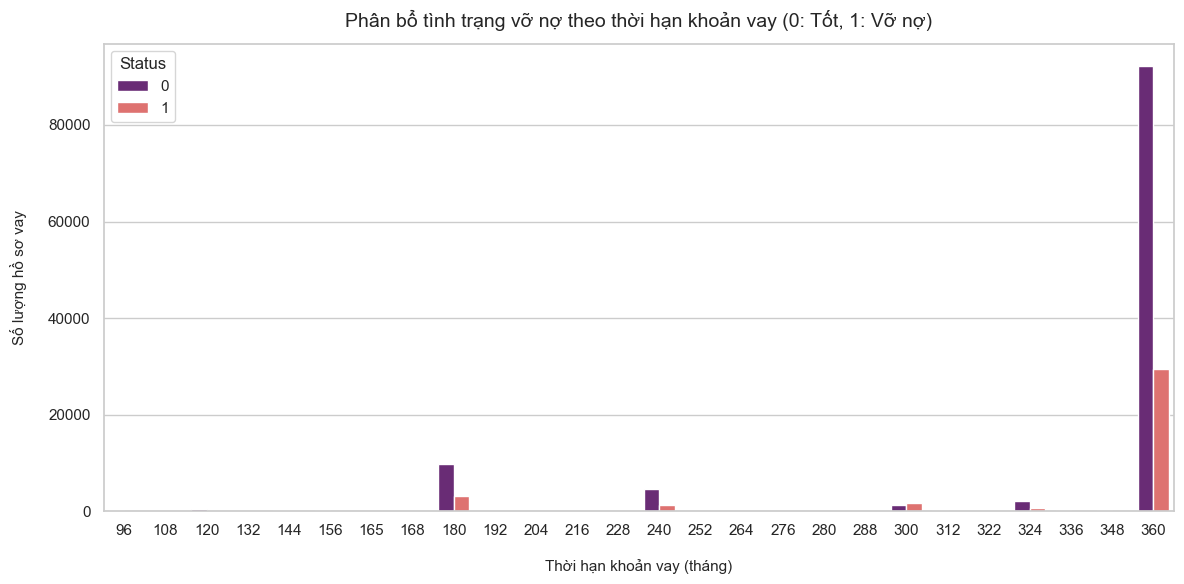

In [22]:
df_term = df.dropna(subset=['term']).copy()
df_term['term'] = df_term['term'].astype(int)

term_counts = df_term['term'].value_counts().sort_index().reset_index()
term_counts.columns = ['Thời hạn khoản vay (tháng)', 'Số lượng hồ sơ']

display(term_counts)

term_order = sorted(df_term['term'].unique())

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_term,
    x='term',
    hue='Status',
    order=term_order,
    width=0.75,
    palette='magma'
)

ax.set_title("Phân bổ tình trạng vỡ nợ theo thời hạn khoản vay (0: Tốt, 1: Vỡ nợ)", fontsize=14, pad=12)
ax.set_xlabel("Thời hạn khoản vay (tháng)", fontsize=11, labelpad=15)
ax.set_ylabel("Số lượng hồ sơ vay", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()

### Insight

- Khoản vay **360 tháng (30 năm)** chiếm tỷ trọng lớn nhất với **121,685 hồ sơ**, tương đương khoảng **82% tổng số khoản vay**. Các mốc thời hạn khác như **180 tháng (12,981 hồ sơ)** và **240 tháng (5,859 hồ sơ)** có số lượng thấp hơn đáng kể, các khoản vay **300 tháng** và **324 tháng** cũng xuất hiện nhưng chiếm tỷ trọng tương đối nhỏ.

- Về tỷ lệ vỡ nợ, các khoản vay dài hạn có xu hướng rủi ro cao hơn so với một số khoản vay ngắn hạn. Cụ thể:
  - **180 tháng:** tỷ lệ vỡ nợ khoảng **24.30%**
  - **240 tháng:** khoảng **20.82%**
  - **300 tháng:** khoảng **56.56%**
  - **324 tháng:** khoảng **25.42%**
  - **360 tháng:** khoảng **24.21%**

- Đáng chú ý, nhóm **300 tháng** có tỷ lệ vỡ nợ **cao vượt trội (56.56%)** so với các nhóm còn lại, mặc dù số lượng hồ sơ của nhóm này tương đối nhỏ.

- Kết quả cho thấy các khoản vay có thời hạn từ **180–360 tháng** đều có tỷ lệ vỡ nợ ở mức đáng kể. Thời gian vay kéo dài có thể làm tăng khả năng chịu tác động của các yếu tố kinh tế như biến động thu nhập, lãi suất hoặc điều kiện thị trường.

- Do đó, biến **term** có ý nghĩa trong việc phản ánh mức độ rủi ro của khoản vay và có thể đóng vai trò quan trọng trong mô hình dự đoán nợ xấu.